# Basics of quantum information - Multiple Systems
Ref: https://quantum.cloud.ibm.com/learning/en/courses/basics-of-quantum-information/multiple-systems/introduction   

In [1]:
from qiskit import __version__

print(__version__)

2.5.1


In [2]:
from qiskit.quantum_info import Statevector, Operator
from IPython.display import Image
from numpy import sqrt

## Tensor products

Tensor Product of 2x2 matrices:


'Row Vector'

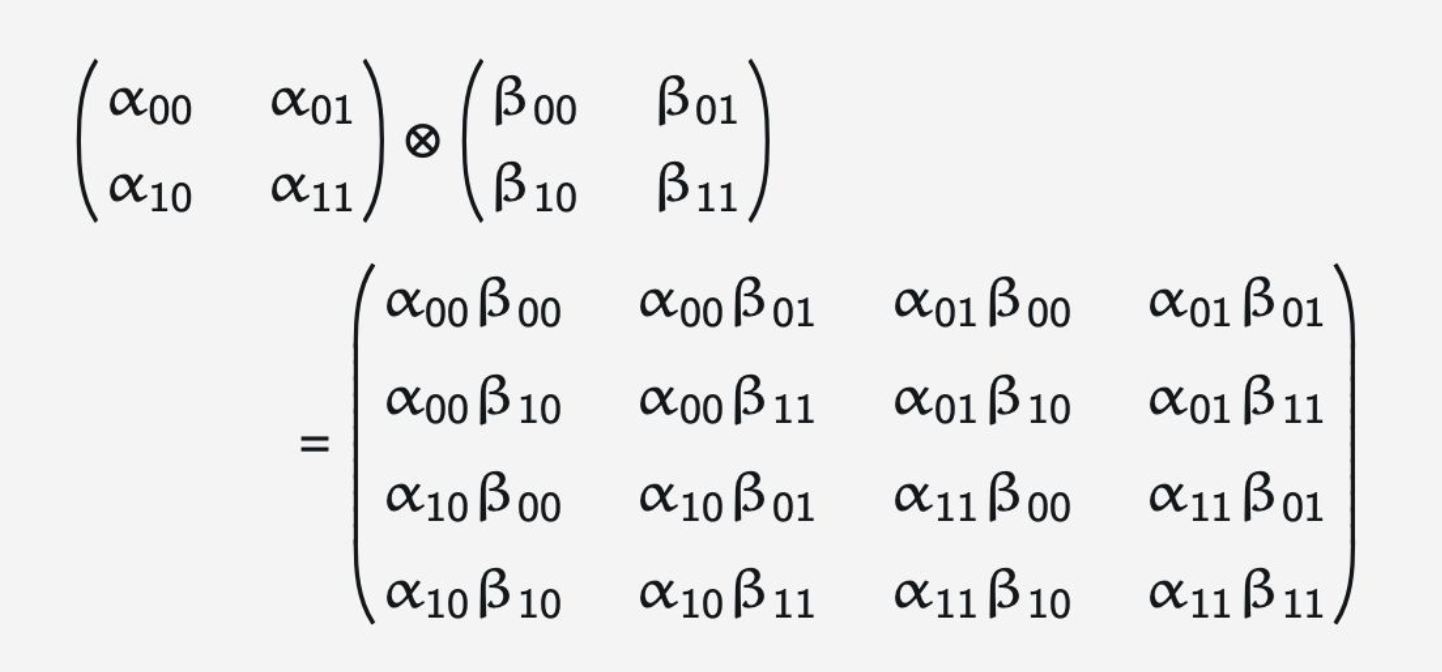

In [3]:
print ("Tensor Product of 2x2 matrices:")

display("Row Vector", Image(filename="../images/tensor-product-example.png",width=500))

In [4]:
zero = Statevector.from_label("0")
one = Statevector.from_label("1")
psi = zero.tensor(one)
display(psi.draw("latex"))

display(psi.data.reshape(-1, 1))

import sympy as sp
display(sp.Matrix(psi.data))

<IPython.core.display.Latex object>

array([[0.+0.j],
       [1.+0.j],
       [0.+0.j],
       [0.+0.j]])

Matrix([
[  0],
[1.0],
[  0],
[  0]])

In [5]:
plus = Statevector.from_label("+")
minus_i = Statevector.from_label("l")
phi = plus.tensor(minus_i)
display(phi.draw("latex"))

display(sp.Matrix(phi.data))


<IPython.core.display.Latex object>

Matrix([
[   0.5],
[-0.5*I],
[   0.5],
[-0.5*I]])

In [6]:
# An alternative is to use the ^ operation for tensor products, which naturally gives the same results.

display((plus ^ minus_i).draw("latex"))

<IPython.core.display.Latex object>

In [7]:
H = Operator.from_label("H")
Id = Operator.from_label("I")
X = Operator.from_label("X")
display(H.tensor(Id).draw("latex"))
display(H.tensor(Id).tensor(X).draw("latex"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [8]:
# Again, like in the vector case, the ^ operation is equivalent.

display((H ^ Id ^ X).draw("latex"))

<IPython.core.display.Latex object>

In [9]:
display(phi.evolve(H ^ Id).draw("latex"))

<IPython.core.display.Latex object>

In [10]:
CX = Operator([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0]])
psi = plus.tensor(zero)
display(psi.evolve(CX).draw("latex"))

<IPython.core.display.Latex object>

## Partial measurements

In [11]:
w = Statevector([0, 1, 1, 0, 1, 0, 0, 0] / sqrt(3))
display(w.draw("latex"))

result, state = w.measure([0])
print(f"Measured: {result}\nState after measurement:")
display(state.draw("latex"))

result, state = w.measure([0, 1])
print(f"Measured: {result}\nState after measurement:")
display(state.draw("latex"))

<IPython.core.display.Latex object>

Measured: 1
State after measurement:


<IPython.core.display.Latex object>

Measured: 00
State after measurement:


<IPython.core.display.Latex object>

## Simple example of quantum circuit

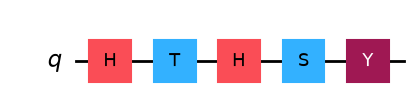

In [25]:
from qiskit import QuantumCircuit

circuit = QuantumCircuit(1)

circuit.h(0)
circuit.t(0)
circuit.h(0)
circuit.s(0)
circuit.y(0)

display(circuit.draw(output="mpl"))

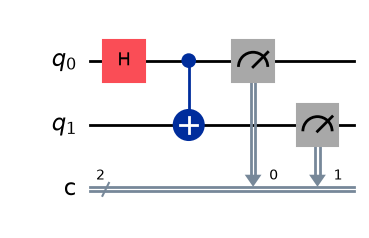

In [ ]:
from qiskit import QuantumCircuit

circuit = QuantumCircuit(2, 2)

circuit.h(0)
circuit.cx(0, 1)
circuit.measure(0, 0)  # q0 → c0
circuit.measure(1, 1)  # q1 → c1

display(circuit.draw(output="mpl"))

{'00': 519, '11': 505}


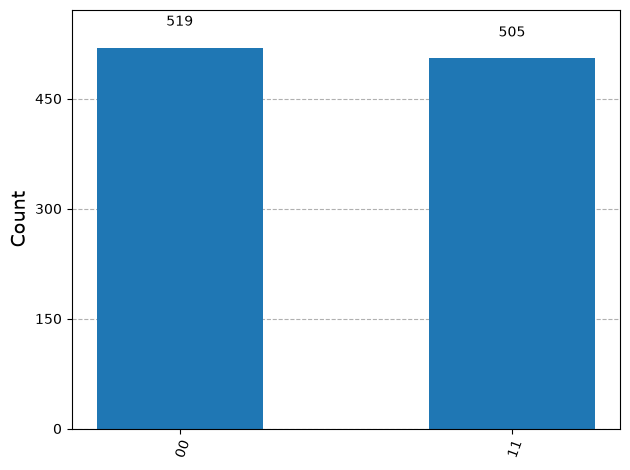

In [23]:
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

# Create simulator
simulator = AerSimulator()

# Run the circuit
job = simulator.run(circuit, shots=1024)

# Get measurement results
result = job.result()
counts = result.get_counts()

print(counts)

# Display histogram
display(plot_histogram(counts))